# Defensive Heat Zones: Base on Statsbomb 360 Data

**defensive event heat zones** (StatsBomb Event data) Can help us identify the defensive heat zones in one or several games.

## 0. Setup & Configuration

Imports, global constants, data-source paths, and the analysis parameters.

In [35]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from mplsoccer import Pitch
from IPython.display import HTML

from statsbombpy import sb

from scipy.optimize import linear_sum_assignment

from tqdm import tqdm

warnings.filterwarnings("ignore",message="credentials not found, using statsbombpy's default credentials")

In [36]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="white")

SB_X, SB_Y = 120.0, 80.0          # StatsBomb pitch is 120 x 80
WATERMARK_NAME     = "Youcheng Song"
WATERMARK_SUBTITLE = "Sports Analytics & Data Science"

Initial_COLOR =  "#004D98" # Use Barcelona blue for the heatmap

# Keep only "full" seasons (>= this many matches) when scanning competitions
FULL_MATCH_THRESHOLD = 100

# ---- Sample team / season (richest free-data coverage: FC Barcelona) ----
SAMPLE_COMP_ID   = 11          # La Liga
SAMPLE_SEASON_ID = 27          # 2015/2016
SAMPLE_TEAM      = "Barcelona" # full 38-match season available in free data

# Define event types for defensive actions
DEFENSIVE_EVENT_TYPES = [
    "Ball Recovery", "Block", "Clearance", "Duel", "Interception", "Pressure"
]
ACTIVE_PRESS_TYPES = {"Pressure", "Interception", "Duel"} 
REACTIVE_DEF_TYPES = {"Block", "Clearance", "Ball Recovery"}

## 1. Exploring Available Competitions and save the games:

We extract all the male games from season 2015-2016 and later.

In [37]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

free_comps = sb.competitions()

comps = free_comps[free_comps["competition_gender"] == "male"].copy()

comps["season_start"]=comps["season_name"].str.split("/").str[0].astype(int)

comps = comps[comps["season_start"] >= 2015].copy()

In [38]:
match_counts = []

for comp_id, season_id in zip(comps["competition_id"], comps["season_id"]):
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        "competition_id": comp_id,
        "season_id": season_id,
        "matches_count": matches_count
    })

match_counts_df = pd.DataFrame(match_counts)

metadata_cols = ["competition_id", "season_id", "competition_name",
                 "season_name", "country_name"]

match_counts_df = match_counts_df.merge(
    comps[metadata_cols],
    on=["competition_id", "season_id"],
    how="left"
)

full_comps = match_counts_df[
    match_counts_df["matches_count"] >= FULL_MATCH_THRESHOLD
].sort_values("matches_count", ascending=False).reset_index(drop=True)

## 2. Selecting the Sample Team: FC Barcelona

Among all free-data seasons, **FC Barcelona** has by far the richest coverage (210 matches overall; a full **38-match** season in **La Liga 2015/2016**), so we use it as the sample for the defensive heat-zone analysis.

We pull every match of the season and keep only the games Barcelona played (home **or** away).

In [39]:
# Pull every match of the sample season, then keep only the sample team's games.
# FC Barcelona, La Liga 2015/2016 -> full 38-match season in StatsBomb free data.
matches_df = sb.matches(competition_id=SAMPLE_COMP_ID, season_id=SAMPLE_SEASON_ID)

team_matches = matches_df[
    (matches_df["home_team"] == SAMPLE_TEAM) | (matches_df["away_team"] == SAMPLE_TEAM)
].sort_values("match_date").reset_index(drop=True)

team_match_ids = team_matches["match_id"].tolist()
print(f"{SAMPLE_TEAM}: {len(team_matches)} matches")

Barcelona: 38 matches


In [40]:
team_matches[["match_id", "match_date", "home_team", "away_team", "home_score", "away_score"]].head()

,match_id,match_date,home_team,away_team,home_score,away_score
0,266236,2015-08-23,Athletic Club,Barcelona,0,1
1,267422,2015-08-29,Barcelona,Málaga,1,0
2,266166,2015-09-12,Atlético Madrid,Barcelona,1,2
3,266490,2015-09-20,Barcelona,Levante UD,4,1
4,266467,2015-09-23,Celta Vigo,Barcelona,4,1


## 3. Extracting Defensive Events

For every match in the sample we pull the full event feed, then keep only **the sample team's** actions whose type is one of the `DEFENSIVE_EVENT_TYPES` defined in the setup cell. All matches are concatenated into a single table `defensive_events`, with the pitch `location` split into `x` / `y` columns ready for heat-zone plotting.

In [41]:
# Fetch the full event feed for each sample match and stack them.
all_events = []
for mid in tqdm(team_match_ids, desc="Fetching events"):
    ev = sb.events(match_id=mid)
    ev["match_id"] = mid
    all_events.append(ev)

events_df = pd.concat(all_events, ignore_index=True)

# Keep only the sample team's defensive actions (types defined in the setup cell).
defensive_events = events_df[
    (events_df["team"] == SAMPLE_TEAM)
    & (events_df["type"].isin(DEFENSIVE_EVENT_TYPES))
].copy()

# Split the [x, y] pitch location into separate columns; drop events without a location.
defensive_events = defensive_events[defensive_events["location"].notna()].reset_index(drop=True)
defensive_events[["x", "y"]] = pd.DataFrame(
    defensive_events["location"].tolist(), index=defensive_events.index
)

print(f"Total events fetched : {len(events_df):,}")
print(f"{SAMPLE_TEAM} defensive events: {len(defensive_events):,}")
display(defensive_events["type"].value_counts())

Fetching events: 100%|██████████| 38/38 [00:16<00:00,  2.31it/s]


Total events fetched : 138,622
Barcelona defensive events: 9,137


type
Pressure         4659
Ball Recovery    1843
Duel             1012
Clearance         689
Block             588
Interception      346
Name: count, dtype: int64

In [42]:
defensive_events[["match_id", "minute", "second", "team", "type", "player", "x", "y"]].head(5)

,match_id,minute,second,team,type,player,x,y
0,266236,0,11,Barcelona,Ball Recovery,Claudio Andrés Bravo Muñoz,14.8,35.0
1,266236,3,31,Barcelona,Ball Recovery,Rafael Alcântara do Nascimento,49.7,32.5
2,266236,7,17,Barcelona,Ball Recovery,Sergio Busquets i Burgos,52.6,36.7
3,266236,12,54,Barcelona,Ball Recovery,Ivan Rakitić,35.8,47.4
4,266236,16,55,Barcelona,Ball Recovery,Jordi Alba Ramos,27.2,21.8


## 4 · Defensive Heat Zones — Plotting

Pitch helper and the KDE heat-zone builder (active pressing / reactive defending / all).

In [43]:
# ------------------------------------------------------------
# 4a · Pitch helper
#     Blank StatsBomb pitch. line_zorder=2 keeps the pitch lines
#     (sidelines, halfway line, boxes) ABOVE the KDE cloud so the
#     pitch stays readable.
# ------------------------------------------------------------
def draw_pitch(ax, title: str = "", line_zorder: int = 2):
    pitch = Pitch(pitch_type="statsbomb", pitch_color="white",
                  line_color="#2b2b2b", linewidth=1.4, line_zorder=line_zorder)
    pitch.draw(ax=ax)
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold")
    return pitch


def annotate_attack_direction(ax, text=f"{SAMPLE_TEAM} attacking direction"):
    """Left-to-right arrow + caption beneath the pitch.

    StatsBomb normalises every team to attack left -> right (towards x=120),
    so Barcelona attacks rightwards and defends the x=0 goal.
    """
    ax.annotate("", xy=(0.70, -0.06), xytext=(0.30, -0.06),
                xycoords="axes fraction", annotation_clip=False,
                arrowprops=dict(arrowstyle="fancy", lw=2.2, color="#555555"))
    ax.text(0.5, -0.115, text, transform=ax.transAxes, ha="center", va="top",
            fontsize=10, color="#555555", clip_on=False)

In [49]:
# ------------------------------------------------------------
# 4b · Heat-zone figure builder (KDE of Barcelona defensive actions)
#     - single team, single pitch per call
#     - pitch lines drawn ABOVE the cloud (no occlusion)
#     - category selected via active / reactive / all
#     - cloud colored with the Barcelona blue (Initial_COLOR)
#     - left-to-right attacking-direction arrow under the pitch
# ------------------------------------------------------------
CATEGORY_LABELS = {
    "active": "Active pressing  (Pressure + Interception + Duel)",
    "reactive": "Reactive defending  (Block + Clearance + Ball Recovery)",
    "all": "All defensive events",
}

# White -> Barcelona blue colormap for the KDE cloud.
TEAM_CMAP = LinearSegmentedColormap.from_list("team_blue", ["white", Initial_COLOR])


def _select_defensive(category: str):
    """Return (subset_df, label) for the requested defensive category."""
    if category == "all":
        return defensive_events, CATEGORY_LABELS["all"]
    if category == "active":
        return defensive_events[defensive_events["type"].isin(ACTIVE_PRESS_TYPES)], CATEGORY_LABELS["active"]
    if category == "reactive":
        return defensive_events[defensive_events["type"].isin(REACTIVE_DEF_TYPES)], CATEGORY_LABELS["reactive"]
    raise ValueError("category must be 'active', 'reactive' or 'all'")


def plot_defensive_heatzone(category: str = "all"):
    """KDE heat zone of Barcelona's defensive actions for the given category."""
    sub, label = _select_defensive(category)
    d = sub[sub["x"].notna() & sub["y"].notna()]

    fig, ax = plt.subplots(figsize=(9, 6.5))
    fig.subplots_adjust(left=0.04, right=0.96, top=0.86, bottom=0.16)

    pitch = draw_pitch(ax, line_zorder=2)
    if len(d) >= 10:
        pitch.kdeplot(d["x"], d["y"], ax=ax, fill=True, levels=100,
                      thresh=0.05, cmap=TEAM_CMAP, alpha=0.9, zorder=1, bw_adjust=0.9)
    else:
        ax.text(60, 40, f"Not enough events: {len(d)}", ha="center", va="center", fontsize=14)

    ax.set_title(SAMPLE_TEAM, fontsize=15, fontweight="bold", color=Initial_COLOR, pad=10)
    annotate_attack_direction(ax)

    fig.suptitle(f"{SAMPLE_TEAM} Defensive Heat Zones — {label}",
                 fontsize=16, fontweight="bold", y=0.965)
    fig.text(0.99, 0.01, f"{WATERMARK_NAME} · {WATERMARK_SUBTITLE}",
             ha="right", va="bottom", fontsize=8, color="#bbbbbb")

    plt.show()
    return fig, ax

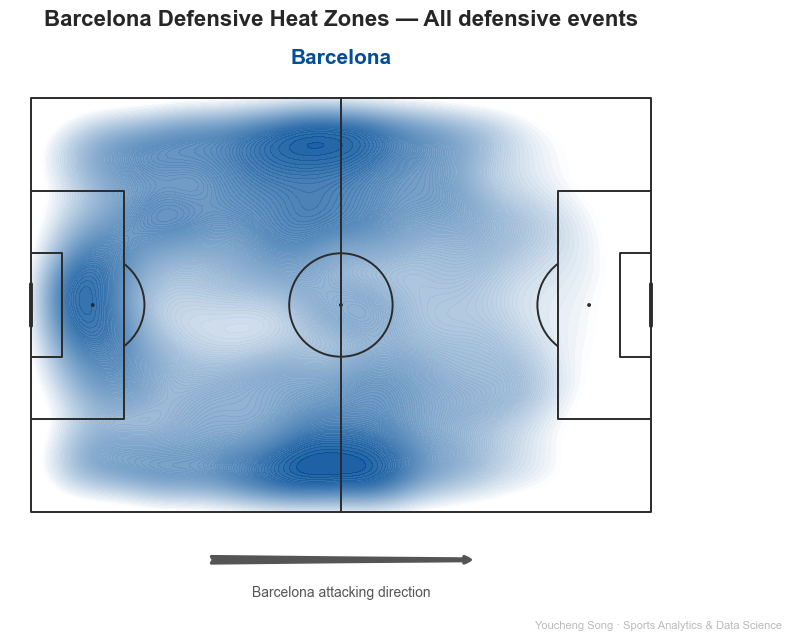

(<Figure size 900x650 with 1 Axes>, <Axes: title={'center': 'Barcelona'}>)

In [61]:
plot_defensive_heatzone(category="all")

## 5 · Defensive Heat Zones — Per Player & Combinations

Slice the defensive heat map down to a **single player** or a **combination of players** (their actions are pooled together).

In [58]:
# ------------------------------------------------------------
# 5a · Defensive roster
#     Players ranked by defensive-action count for a category,
#     broken down by event type (reuses _select_defensive).
# ------------------------------------------------------------
def defensive_roster(category: str = "all", top_n: int | None = None) -> pd.DataFrame:
    """Players ranked by defensive-action count, broken down by event type."""
    sub, _ = _select_defensive(category)
    sub = sub[sub["player"].notna()]

    tab = sub.pivot_table(index="player", columns="type",
                          aggfunc="size", fill_value=0)
    tab["Total"] = tab.sum(axis=1)
    tab = tab.sort_values("Total", ascending=False)
    return tab if top_n is None else tab.head(top_n)

In [ ]:
# ------------------------------------------------------------
# 5b · Per-player / per-combination heat-zone builder
#     Same KDE style as 4b, but sliced to one player or a pooled
#     combination. Falls back to a scatter when actions < min_kde.
# ------------------------------------------------------------
def plot_player_defensive_kde(players, category: str = "all", min_kde: int = 25):
    """Defensive density for one player or a combination of players.

    players  : a name (str) or list of names; a list pools their actions together.
    category : 'all' | 'active' | 'reactive'.
    min_kde  : below this many actions, fall back to a scatter instead of a KDE.
    """
    if isinstance(players, str):
        players = [players]

    known = set(defensive_events["player"].dropna().unique())
    missing = [p for p in players if p not in known]
    if missing:
        print("WARN: not found in defensive events:", missing)
    players = [p for p in players if p in known]
    if not players:
        print("No valid players to plot.")
        return

    sub, label = _select_defensive(category)
    sub = sub[sub["player"].isin(players)]
    d = sub[sub["x"].notna() & sub["y"].notna()]
    who = players[0] if len(players) == 1 else f"{len(players)} players: " + ", ".join(players)

    fig, ax = plt.subplots(figsize=(9, 6.5))
    fig.subplots_adjust(left=0.04, right=0.96, top=0.86, bottom=0.16)

    pitch = draw_pitch(ax, line_zorder=2)

    ax.set_title(who, fontsize=14, fontweight="bold", color=Initial_COLOR, pad=10)
    annotate_attack_direction(ax)

    fig.suptitle(f"{SAMPLE_TEAM} Defensive density — {label}",
                 fontsize=15, fontweight="bold", y=0.965)
    fig.text(0.99, 0.01, f"{WATERMARK_NAME} · {WATERMARK_SUBTITLE}",
             ha="right", va="bottom", fontsize=8, color="#bbbbbb")

    plt.show()
    return fig, ax

In [63]:
# Rosters: wrap in display() so both tables render (only the last
# expression in a cell auto-displays otherwise).
display(defensive_roster(category="all"))               # full defensive-action ranking

type,Ball Recovery,Block,Clearance,Duel,Interception,Pressure,Total
player,,,,,,,
Sergio Busquets i Burgos,152,64,67,149,38,582,1052
Ivan Rakitić,148,39,28,81,31,480,807
Javier Alejandro Mascherano,110,69,106,105,38,354,782
Daniel Alves da Silva,164,63,33,95,29,381,765
Jordi Alba Ramos,144,64,77,69,41,304,699
Gerard Piqué Bernabéu,149,49,156,74,32,184,644
Andrés Iniesta Luján,133,30,13,63,12,377,628
Neymar da Silva Santos Junior,134,29,3,54,13,392,625
Sergi Roberto Carnicer,95,27,21,72,23,338,576


NameError: name 'note' is not defined

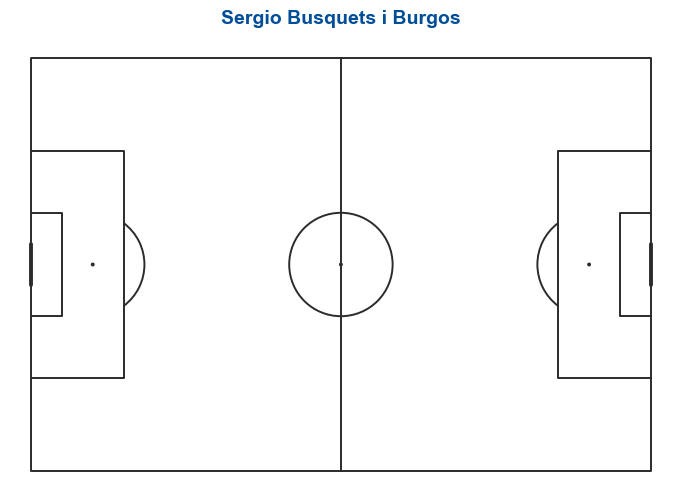

In [68]:
# Heat zones: a single player, then a pooled centre-back combination.
plot_player_defensive_kde("Sergio Busquets i Burgos")   # single player
plot_player_defensive_kde(                              # centre-back pairing
    ["Gerard Piqué Bernabéu", "Javier Alejandro Mascherano"],
    category="reactive",
)